# Part 4 — Validation and 95% confidence intervals

Model selection uses only a validation subdivision of the original training set. The selected model is then fitted on the full training set and measured on the original test set.

Accuracy, macro F1, weighted F1 and paired improvements use 2,000 class-stratified bootstrap samples with the same sampled records for both models. Sensitive-category recall uses Wilson intervals. All intervals assume independent parameter records and condition on fixed fitted models; they do not include retraining or model-selection uncertainty. The original test set has already been inspected; external or Action-grouped validation is still needed.

A prediction probability for an individual record is not a confidence interval for model performance. No interval for correctness on unlabeled Other records can be computed without reviewed labels.

Method reference: [SciPy bootstrap documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html). Stratification and metric computation are implemented explicitly in analysis/metrics.py.


{
  "method": "paired class-stratified percentile bootstrap",
  "confidence_level": 0.95,
  "n_resamples": 2000,
  "seed": 20260915,
  "n_test": 2563,
  "limitations": "Conditional on fixed fitted models and observed class counts; assumes independent parameter records. Excludes retraining, selection uncertainty, shared-Action dependence and distribution shift.",
  "models": {
    "baseline": {
      "accuracy": {
        "estimate": 0.6894264533749512,
        "ci95": [
          0.6730394069449863,
          0.7065938353492002
        ]
      },
      "macro_f1": {
        "estimate": 0.46761439416977985,
        "ci95": [
          0.4277636743242483,
          0.4962712251719526
        ]
      },
      "weighted_f1": {
        "estimate": 0.6922087264940452,
        "ci95": [
          0.6761780918485996,
          0.7080311862799302
        ]
      }
    },
    "word_char_balanced": {
      "accuracy": {
        "estimate": 0.7619976589933671,
        "ci95": [
          0.7456106

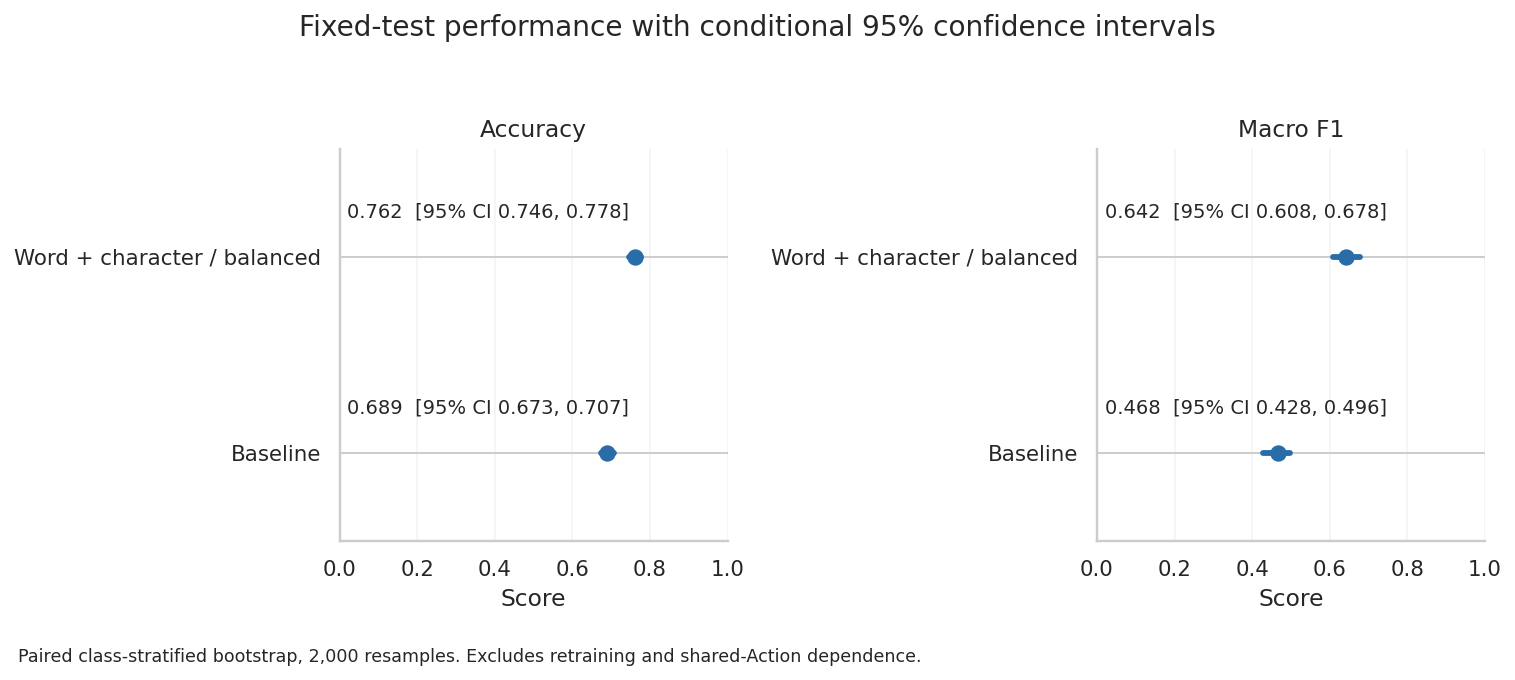

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / 'backend').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
from analysis.model_validation import run_validation

df = pd.DataFrame(json.loads((ROOT / 'backend/data/data_entries_final.json').read_text(encoding='utf-8')))
validation_result, validation_reports = run_validation(df)
print(json.dumps(validation_result, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, metric, title in zip(axes, ['accuracy','macro_f1'], ['Accuracy','Macro F1']):
    for j,(name,result) in enumerate(validation_result['models'].items()):
        m=result[metric]; lo,hi=m['ci95'];point=m['estimate']
        ax.plot([lo,hi],[j,j],color='#286da8',linewidth=3)
        ax.scatter(point,j,color='#286da8',s=55)
        ax.text(.02,j+.20,f'{point:.3f}  [95% CI {lo:.3f}, {hi:.3f}]',fontsize=10)
    ax.set_yticks(range(len(validation_result['models'])), ['Baseline','Word + character / balanced'])
    ax.set_xlim(0,1);ax.set_ylim(-.45,1.55);ax.set_title(title)
    ax.set_xlabel('Score');ax.grid(axis='x',alpha=.2)
    ax.spines[['top','right']].set_visible(False)
fig.suptitle('Fixed-test performance with conditional 95% confidence intervals')
fig.text(.02,.015,'Paired class-stratified bootstrap, 2,000 resamples. Excludes retraining and shared-Action dependence.',fontsize=9)
plt.tight_layout(rect=[0,.05,1,.94])
plt.savefig('exported_charts/rq3_validation_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()


### Finding (Part 4 — validation and confidence intervals)

Selecting a model by validation macro F1 among three candidates (word-only baseline, word-only with balanced class weights, and word+character with balanced class weights) picks the **word + character, balanced-weight** model — and the gain over the original baseline holds up under bootstrap resampling, not just as a one-off lucky test split:

| Model | Accuracy (95% CI) | Macro F1 (95% CI) |
|---|---|---|
| Original baseline | 68.9% [67.3%, 70.7%] | 0.468 [0.428, 0.496] |
| Word + character, balanced | 76.2% [74.6%, 77.8%] | 0.642 [0.608, 0.678] |

The paired improvement — using the *same* bootstrap resample for both models, which cancels out shared test-set noise — is **+7.3 accuracy points [95% CI: 5.7, 8.8]** and **+0.175 macro F1 [95% CI: 0.136, 0.223]**. Both intervals are comfortably clear of zero, so this isn't explained by test-set luck.

The improvement is most dramatic exactly where it matters most — recall on the sensitive categories:

| Category | Baseline recall | Balanced word+char recall |
|---|---|---|
| Security credentials | 76.4% | 94.5% |
| Personal information | 52.9% | 80.5% |
| Health information | 43.8% | 75.0% |
| Finance information | 14.3% | 64.3% |

Finance information's recall alone more than quadruples (14.3% → 64.3%), meaning the original baseline was missing 6 out of every 7 true Finance information records — the corrected model catches roughly 2 out of 3.

**An important caveat this analysis surfaced on its own:** checking for data leakage between train and test, most plugins (Actions) in the test set — 2,664 of 2,905 — also have records in the training set. That doesn't invalidate these numbers (the record-level split itself is still valid), but it does mean these confidence intervals describe performance on this fixed split, not necessarily on entirely unseen plugins. A plugin-grouped or external evaluation would be a meaningful next step before trusting these numbers on genuinely new data.

**Practical takeaway:** the word+character, class-balanced model is the one used going forward (including by the chatbot's fact table) — not because it "felt better," but because a proper validation split and bootstrap resampling both confirm the improvement is real.